# Multi-Agent Observability & Evaluation — Demo

### A production-style showcase of how to *see* and *measure* AI agents

---

## What is this?

An end-to-end framework that runs AI **web-navigation agents** against the
[Mind2Web](https://osu-nlp-group.github.io/Mind2Web/) benchmark (NeurIPS 2023) and
instruments every step with **OpenTelemetry-compliant tracing** and a rigorous
**multi-layer evaluation** stack. It compares a **single ReAct agent** against a
**Multi-Agent System (MAS)** built on the supervisor pattern:

> **Supervisor → Planner → Navigator → Validator**

## Why does it matter?

As autonomous agents move into production, two questions become mission-critical:

1. **Observability** — *Can you see what the agent did?* Every LLM call, routing
   decision, and tool invocation is captured as an OTel span you can ship to
   Datadog, Splunk, Phoenix, or Langfuse — an auditable record of *how* a result
   was reached, not just *that* it finished.
2. **Evaluation** — *Can you prove it did the right thing?* A hybrid scorer
   (deterministic rules + LLM-as-judge), tool-selection correctness, and safety
   checks quantify quality, cost, latency, and health.

## The story this demo tells

A single agent is simple and cheap, but it has to plan, act, and self-check all at
once. A **Multi-Agent System decomposes the work** — a Planner decides the steps, a
Navigator executes them with tools, and a Validator independently checks the result.
On harder, multi-step tasks this division of labor can **lift task quality** at the
cost of more tokens and latency. This notebook runs **both systems on the same
tasks** and puts the trade-off side by side, so you can decide *when orchestration is
worth it*.

## Value

- **Provider-agnostic** — Azure OpenAI, OpenAI, Ollama, Groq, Together (via `.env`)
- **Audit-ready** — OTLP trace export + per-agent cost attribution
- **Coding-light** — all logic lives in `src/`; this notebook is the narrative
- **Reusable** — swap in your own agents, tools, or benchmark

---


## Step 1 — Install & Import

All implementation lives in `src/` — this notebook stays deliberately coding-light.

| Symbol | Role |
|---|---|
| `Config` | Provider-agnostic LLM factory + cost table |
| `TracingManager`, `HierarchicalTracer` | Per-task trace + OpenTelemetry span tree |
| `CostTracker`, `HealthMonitor` | Cost rollups + rolling-window health |
| `SafetyValidator` | PII / injection / harmful-content checks |
| `load_mind2web`, `Mind2WebTask` | Benchmark loader + task object |
| `create_baseline_agent`, `run_agent` | Single ReAct agent |
| `create_multi_agent`, `run_multi_agent` | Supervisor → Planner → Navigator → Validator |
| `evaluate_batch` | Runs N tasks through either system → tidy DataFrame |
| `HybridEvaluator`, `ToolCorrectnessEval` | Scoring engines |
| `plot_*` | Dashboards, trace tree, single-vs-multi comparison |

> `%autoreload 2` is enabled, so edits under `src/` take effect without a kernel restart.

In [1]:
# Uncomment on first run:
# !pip install -r requirements.txt

%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '.')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd

from src import (
    Config,
    TracingManager, HierarchicalTracer,
    CostTracker, HealthMonitor,
    SafetyValidator,
    load_mind2web,
    Mind2WebTask,
    create_baseline_agent, run_agent,
    create_multi_agent, run_multi_agent,
    evaluate_batch,
    HybridEvaluator, ToolCorrectnessEval,
    plot_eval_dashboard, plot_trace_tree, plot_telemetry_dashboard,
    plot_dataset_overview, plot_baseline_vs_multi,
)

print('✅ All imports successful')

✅ All imports successful


In [2]:
import sys
!{sys.executable} -m pip install arize-phoenix openinference-instrumentation-langchain opentelemetry-sdk opentelemetry-exporter-otlp

## Step 2 — Configuration

Settings come from your `.env` (copied from `.env.example`) — **no hardcoded
credentials**. Provider is auto-detected: `OPENAI_API_VERSION` set → Azure OpenAI;
blank → OpenAI / Ollama / Groq / any compatible endpoint.

**Per-specialist models (optional).** The multi-agent system can give each role its
own model. By default Planner/Navigator/Supervisor use `AGENT_MODEL` and Validator
uses `JUDGE_MODEL`, but you can override in `.env` — e.g. a cheap Planner and a
strong Navigator:

```
PLANNER_MODEL=gpt-4o-mini
NAVIGATOR_MODEL=gpt-4o
VALIDATOR_MODEL=gpt-4.1
```

> **Tip:** use a *different* model for the judge/validator than the agent to reduce
> self-evaluation bias.

In [3]:
Config.setup_dirs()

print('Provider:    ', 'Azure OpenAI' if Config.API_VERSION else 'OpenAI / compatible')
print('Agent model: ', Config.AGENT_MODEL)
print('Judge model: ', Config.JUDGE_MODEL)
print('MAS models:  ', {
    'supervisor': Config.SUPERVISOR_MODEL, 'planner': Config.PLANNER_MODEL,
    'navigator':  Config.NAVIGATOR_MODEL,  'validator': Config.VALIDATOR_MODEL,
})
print('Pass threshold:', Config.EVAL_PASS_THRESHOLD)
print('Output dir:    ', Config.OUTPUT_DIR)

Provider:     Azure OpenAI
Agent model:  gpt-5-4-20260305-gs
Judge model:  gpt-4-1-20250414-gs
MAS models:   {'supervisor': 'gpt-5-4-20260305-gs', 'planner': 'gpt-5-4-20260305-gs', 'navigator': 'gpt-5-4-20260305-gs', 'validator': 'gpt-4-1-20250414-gs'}
Pass threshold: 0.7
Output dir:     outputs


## Step 3 — Verify LLM Connectivity

A quick smoke test before spending time on the full pipeline — one tiny call to the
agent model and one to the judge model. Catches auth errors, wrong deployment names,
and IP-allowlist blocks *early*. If either errors, fix `.env` (see
[`docs/provider-setup.md`](docs/provider-setup.md)) before continuing.

In [4]:
from langchain_core.messages import HumanMessage

agent_llm = Config.create_llm(role='agent')
judge_llm = Config.create_llm(role='judge')

print('Agent LLM ✅:', agent_llm.invoke([HumanMessage(content='Say hello in 5 words.')]).content.strip())
print('Judge LLM ✅:', judge_llm.invoke([HumanMessage(content='Reply with the single digit 1.')]).content.strip())

Agent LLM ✅: Hello there, nice to meet you.
Judge LLM ✅: 1


## Step 4 — Load the Mind2Web Benchmark (Test Data)

[**Mind2Web**](https://osu-nlp-group.github.io/Mind2Web/) (NeurIPS 2023, OSU NLP) is
the first large-scale benchmark for agents that follow natural-language instructions
to navigate **real websites** — 2,000+ tasks across 137 sites and 31 domains.

We stream `osunlp/Multimodal-Mind2Web` from HuggingFace, keeping only lightweight
**text metadata** (skipping HTML/screenshots). Each task has a `confirmed_task`, a
`website`/`domain`, and `action_reprs` — the **gold reference action sequence** used
to score tool correctness. First run caches ~300 tasks to `outputs/data/`.

> The framework scores the agent's *plan* against these references in a safe
> sandbox — it does not drive a live browser against the real site.

In [5]:
raw_tasks = load_mind2web(Config.DATA_DIR, target_tasks=Config.MIND2WEB_TARGET_TASKS)
print(f'Loaded {len(raw_tasks)} tasks. Sample: {raw_tasks[0]["confirmed_task"][:90]}')

Using cached dataset: 300 tasks (outputs/data/mind2web_train.jsonl)
Loaded 300 tasks. Sample: rent a car in Brooklyn - Central, NY on from April 9 to April 15.


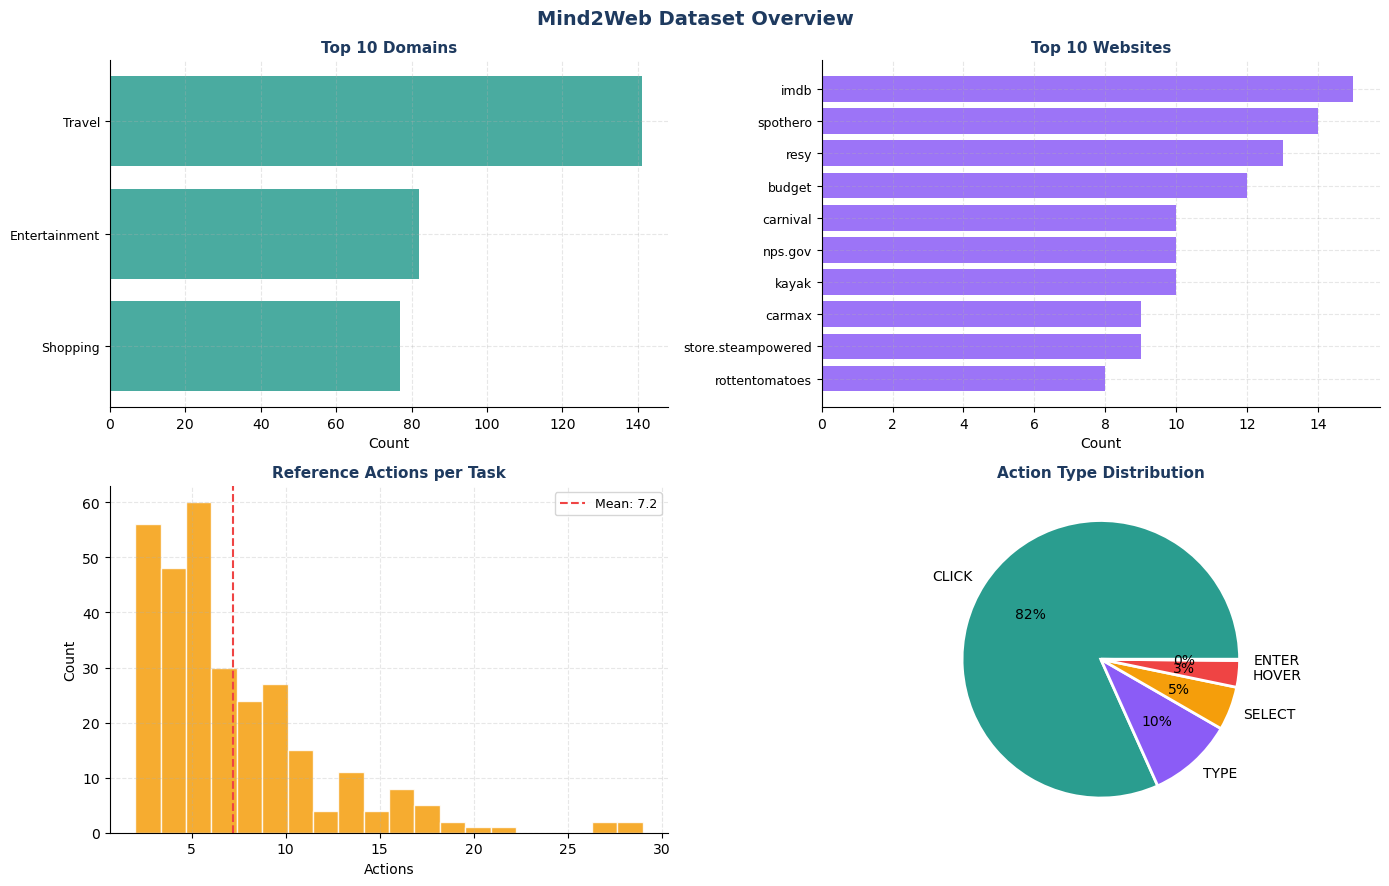

In [6]:
fig = plot_dataset_overview(raw_tasks, save_path=Config.OUTPUT_DIR / 'dataset_overview.png')

## Step 5 — Build Both Systems

We initialize the shared observability/monitoring components, then build **both
architectures** so they can be compared on identical tasks.

**Single-Agent (baseline)** — one ReAct agent with all 11 hybrid tools. Plans, acts,
and answers in a single loop.

**Multi-Agent System (MAS)** — the supervisor pattern, each specialist with its own
role, model, and OTel span:

| Specialist | Role | Tools? |
|---|---|---|
| **Supervisor** | Routes the pipeline | no |
| **Planner** | Decomposes task into 3–5 steps | no |
| **Navigator** | Executes the plan with tools | **yes** |
| **Validator** | Independently judges completion/quality | no |

**Tools** (`src/tools.py`) are *hybrid real + mock*: READ tools fetch live data when
keys are present (Tavily) else realistic mocks; WRITE tools (book/purchase/submit)
are **always mocked** — no real transactions.

In [7]:
# Shared observability + monitoring
tracing_manager = TracingManager()
hier_tracer     = HierarchicalTracer()
cost_tracker    = CostTracker()
health_monitor  = HealthMonitor(window_size=50)

# Both systems
agent, judge_llm = create_baseline_agent(Config)
multi_agents     = create_multi_agent(Config)

# Shared evaluator
evaluator = HybridEvaluator(judge_llm,
                            pass_threshold=Config.EVAL_PASS_THRESHOLD,
                            rule_weight=Config.RULE_WEIGHT,
                            llm_weight=Config.LLM_WEIGHT)

print('✅ Single-agent + Multi-agent systems ready')
print('   MAS specialists:', list(multi_agents['models'].keys()))

✅ Single-agent + Multi-agent systems ready
   MAS specialists: ['supervisor', 'planner', 'navigator', 'validator']


### (Optional) Enable real OpenTelemetry → Arize Phoenix

By default the framework records a **local** span tree (`HierarchicalTracer`) for the
offline trace-tree chart and OTLP export. To stream **real, live OpenTelemetry spans**
to a backend instead, run the cell below — it launches a local [Phoenix](https://phoenix.arize.com)
app and **auto-instruments LangChain/LangGraph** (no other code changes needed):

```bash
pip install arize-phoenix openinference-instrumentation-langchain opentelemetry-sdk opentelemetry-exporter-otlp
```

Once active, open **http://localhost:6006** to watch agent runs as they happen. Point
`endpoint=` at any OTLP collector (Datadog, Jaeger, Grafana Tempo, Langfuse) to ship
elsewhere. If the packages aren't installed, this is a safe no-op and the demo
continues with the local tracer.

Separately, **token & cost are now measured from real API usage** (via LangChain's
usage callback) whenever the model returns it — the `tokens_source` column reads
`api` instead of `estimated`.

In [8]:
from src import setup_phoenix

# Safe no-op if Phoenix isn't installed. Pass endpoint="http://collector:4317"
# to ship to a different OTLP backend, or launch_local=False to attach only.
tracer_provider = setup_phoenix(project_name="multi-agent-otel-eval")

boto3 is installed but aioboto3 is not. To use AWS Bedrock models in Playground, install aioboto3: pip install aioboto3


🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix
🌐 Phoenix UI: http://localhost:6006
🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: multi-agent-otel-eval
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

✅ Real OpenTelemetry tracing active → project 'multi-agent-otel-eval' → Phoenix (localhost:6006)
   LangChain / LangGraph runs are now auto-traced as OTel spans.


## Step 6 — Dry Run (1 task, both systems)

Verify the full pipeline on a single task for **each** architecture before the batch.
Both emit an OpenTelemetry span tree (`task.execute → … → tool.execute`). Note how the
multi-agent run shows the per-specialist breakdown in its reasoning steps.

In [9]:
task = Mind2WebTask.from_dict(raw_tasks[0], idx=0)

# Single agent
out_s, tr_s = run_agent(task, agent, tracing_manager, Config, hier_tracer)
print(f'[Single]  latency={tr_s.latency_ms:.0f}ms  tools={len(tr_s.tool_calls)}  cost=${tr_s.total_cost:.5f}')

# Multi-agent
out_m, tr_m = run_multi_agent(task, multi_agents, hier_tracer, tracing_manager, Config)
print(f'[MAS]     latency={tr_m.latency_ms:.0f}ms  tools={len(tr_m.tool_calls)}  cost=${tr_m.total_cost:.5f}')
print('  per-agent:', tr_m.reasoning_steps)

# Reset so the dry run does not pollute the batch metrics
tracing_manager.reset(); health_monitor.reset(); hier_tracer.reset()

[Single]  latency=11486ms  tools=5  cost=$0.02535
[MAS]     latency=27597ms  tools=12  cost=$0.05262
  per-agent: ['Planner: 284 tok / $0.00178', 'Navigator: 12 tools, 17991 tok / $0.04893', 'Validator: YES/HIGH, $0.00191']


## Step 7 — Single-Agent Baseline (N tasks)

Run the baseline ReAct agent over `QUICK_TEST_N` tasks. `evaluate_batch` applies the
full evaluation stack per task — task completion (rule + LLM judge), tool correctness
(precision/recall/F1), safety, plus cost/latency/health — and returns a DataFrame.

This is our **reference point** for the comparison.

In [10]:
N = Config.QUICK_TEST_N

df_single, _ = evaluate_batch(
    raw_tasks, N, mode='single',
    agent=agent, evaluator=evaluator,
    hier_tracer=hier_tracer, tracing_manager=tracing_manager,
    cost_tracker=cost_tracker, health_monitor=health_monitor, config=Config,
)
df_single.head()

Single-Agent: running 10 tasks
[1/10] united: rent a car in Brooklyn - Central, NY on from April 9 to…
  ✅ score=0.75 tool_f1=0.33 tools=9 cost=$0.0301 latency=8070ms
[2/10] ign: Show computer game reviews sorted by score.…
  ✅ score=0.72 tool_f1=0.67 tools=4 cost=$0.0189 latency=6717ms
[3/10] discogs: Find the address and store hours for the Armageddon Sho…
  ❌ score=0.45 tool_f1=0.00 tools=3 cost=$0.0166 latency=6108ms
[4/10] discogs: Buy a copy of the Gorillaz first studio album.…
  ✅ score=0.74 tool_f1=0.67 tools=6 cost=$0.0286 latency=11442ms
[5/10] discogs: Buy a pop rock album CD from the United Kingdom that wa…
  ❌ score=0.48 tool_f1=0.33 tools=4 cost=$0.0223 latency=11171ms
[6/10] budget: Find a full-time job in Budget USA in finance in any lo…
  ✅ score=0.93 tool_f1=0.29 tools=19 cost=$0.0901 latency=33820ms
[7/10] budget: What is the cheapest luxury car to pickup on the second…
  ❌ score=0.52 tool_f1=0.00 tools=4 cost=$0.0204 latency=8587ms
[8/10] budget: Book the cheapest l

,task_id,website,system,task_score,task_passed,rule_score,llm_score,tool_f1,tool_precision,tool_recall,n_tool_calls,latency_ms,agent_tokens,judge_tokens,total_cost,tokens_source,safety_passed,errors
0,0,united,Single-Agent,0.752308,True,0.830769,0.7,0.333333,0.20,1.00,9,8069.559097,9672,1042,0.030104,api,True,0
1,1,ign,Single-Agent,0.722857,True,0.757143,0.7,0.666667,0.50,1.00,4,6716.778994,5739,902,0.018942,api,True,0
2,2,discogs,Single-Agent,0.450000,False,0.525000,0.4,0.000000,0.00,0.00,3,6107.869148,4741,921,0.016627,api,True,0
3,3,discogs,Single-Agent,0.740000,True,0.800000,0.7,0.666667,0.60,0.75,6,11441.917896,8838,1105,0.028618,api,True,0
4,4,discogs,Single-Agent,0.480000,False,0.450000,0.5,0.333333,0.25,0.50,4,11170.534849,6427,1077,0.022324,api,True,0


## Step 8 — Multi-Agent System (same N tasks) ⭐

Now the focus: run the **MAS** over the *same* tasks. Each task flows through
Supervisor → Planner → Navigator → Validator, with every specialist traced and
cost-attributed individually.

Watch the per-task line: the MAS typically makes **more tool calls** (the Navigator
follows an explicit plan) and costs **more** (4 LLM roles vs. 1) — the question Step 9
answers is whether that buys **higher task quality**.

In [11]:
df_multi, _ = evaluate_batch(
    raw_tasks, N, mode='multi',
    multi_agents=multi_agents, evaluator=evaluator,
    hier_tracer=hier_tracer, tracing_manager=tracing_manager,
    config=Config,
)
df_multi.head()

Multi-Agent: running 10 tasks
[1/10] united: rent a car in Brooklyn - Central, NY on from April 9 to…
  ✅ score=0.80 tool_f1=0.29 tools=16 cost=$0.0302 latency=17660ms
[2/10] ign: Show computer game reviews sorted by score.…
  ✅ score=0.92 tool_f1=0.67 tools=9 cost=$0.0344 latency=16592ms
[3/10] discogs: Find the address and store hours for the Armageddon Sho…
  ✅ score=0.78 tool_f1=0.50 tools=10 cost=$0.0427 latency=20285ms
[4/10] discogs: Buy a copy of the Gorillaz first studio album.…
  ✅ score=0.73 tool_f1=0.50 tools=10 cost=$0.0434 latency=19760ms
[5/10] discogs: Buy a pop rock album CD from the United Kingdom that wa…
  ✅ score=0.83 tool_f1=0.25 tools=8 cost=$0.0351 latency=19221ms
[6/10] budget: Find a full-time job in Budget USA in finance in any lo…
  ✅ score=0.91 tool_f1=0.33 tools=13 cost=$0.0560 latency=25092ms
[7/10] budget: What is the cheapest luxury car to pickup on the second…
  ✅ score=0.81 tool_f1=0.44 tools=14 cost=$0.0609 latency=26787ms
[8/10] budget: Book the che

,task_id,website,system,task_score,task_passed,rule_score,llm_score,tool_f1,tool_precision,tool_recall,n_tool_calls,latency_ms,agent_tokens,judge_tokens,total_cost,tokens_source,safety_passed,errors
0,0,united,Multi-Agent,0.803077,True,0.807692,0.8,0.285714,0.166667,1.000000,16,17659.803152,9806,726,0.030184,api,True,0
1,1,ign,Multi-Agent,0.920000,True,0.800000,1.0,0.666667,0.500000,1.000000,9,16592.453003,11738,689,0.034356,api,True,0
2,2,discogs,Multi-Agent,0.780000,True,0.900000,0.7,0.500000,0.400000,0.666667,10,20285.471916,14407,760,0.042657,api,True,0
3,3,discogs,Multi-Agent,0.726667,True,0.766667,0.7,0.500000,0.500000,0.500000,10,19759.539843,14484,795,0.043407,api,True,0
4,4,discogs,Multi-Agent,0.827273,True,0.718182,0.9,0.250000,0.166667,0.500000,8,19221.214056,11046,820,0.035083,api,True,0


## Step 9 — Single-Agent vs. Multi-Agent: The Comparison

The headline of the demo. We line up both systems on the same tasks across the
dimensions that matter: **task quality, tool correctness, cost, and latency**.

- If the MAS scores **higher** on `task_score` / pass rate, decomposition helped.
- If it costs **more** for little gain, a single agent is the better default.
- The right choice is **task-dependent** — complex, multi-step tasks favor the MAS;
  simple lookups favor the single agent.

In [12]:
def _avg(df, col):
    return df[col].mean()

rows = []
for label, df in [('Single Agent', df_single), ('Multi-Agent', df_multi)]:
    rows.append({
        'System':       label,
        'Pass rate':    f"{_avg(df,'task_passed')*100:.0f}%",
        'Avg score':    f"{_avg(df,'task_score'):.3f}",
        'Tool F1':      f"{_avg(df,'tool_f1'):.3f}",
        'Avg cost':     f"${_avg(df,'total_cost'):.4f}",
        'Avg latency':  f"{_avg(df,'latency_ms'):.0f}ms",
        'Avg tools':    f"{_avg(df,'n_tool_calls'):.1f}",
    })
comparison = pd.DataFrame(rows).set_index('System')
comparison

,Pass rate,Avg score,Tool F1,Avg cost,Avg latency,Avg tools
System,,,,,,
Single Agent,60%,0.697,0.399,$0.0346,13148ms,7.5
Multi-Agent,100%,0.809,0.462,$0.0414,19902ms,10.9


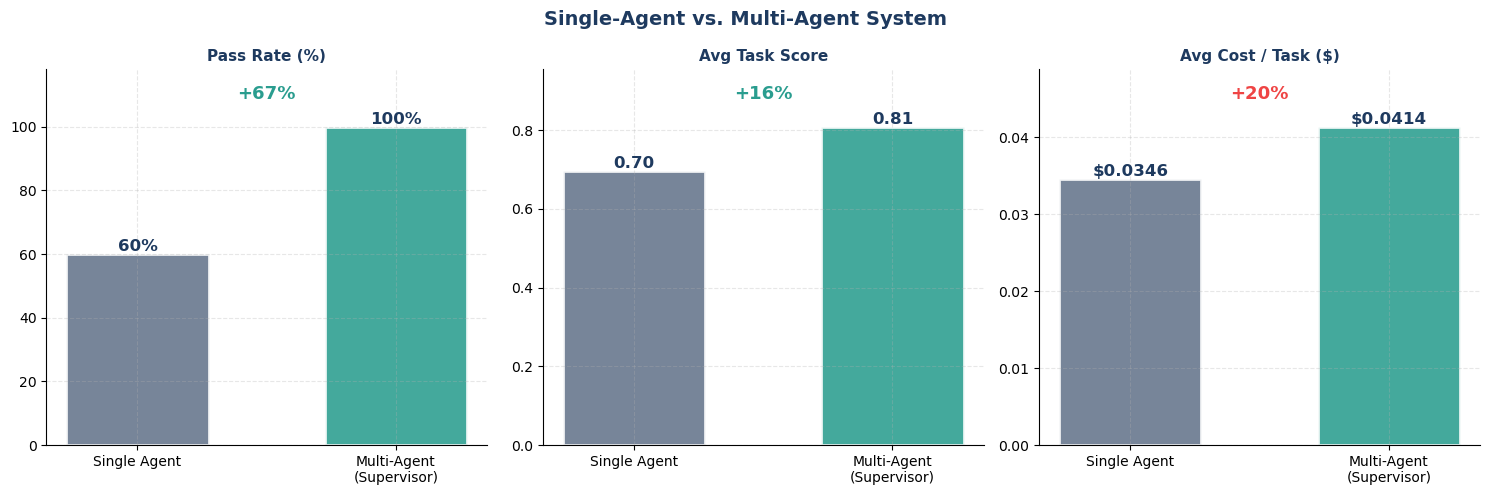

In [13]:
fig = plot_baseline_vs_multi(df_single, df_multi,
                            save_path=Config.OUTPUT_DIR / 'baseline_vs_multi.png')

In [14]:
# Auto-generated interpretation of the run
d_score = _avg(df_multi,'task_score') - _avg(df_single,'task_score')
d_cost  = _avg(df_multi,'total_cost') - _avg(df_single,'total_cost')
cost_x  = _avg(df_multi,'total_cost') / max(_avg(df_single,'total_cost'), 1e-9)

print('INTERPRETATION')
print('-'*60)
print(f"Task score:  {'MAS higher' if d_score>0 else 'Single higher'} by {abs(d_score):.3f}")
print(f"Cost:        MAS is {cost_x:.1f}x the single-agent cost (+${d_cost:.4f}/task)")
if d_score > 0.02:
    print('\n→ The Multi-Agent System improved task quality. The extra cost')
    print('  buys better planning and an independent validation check —')
    print('  worth it for complex, multi-step tasks.')
elif d_score < -0.02:
    print('\n→ The single agent matched or beat the MAS here. For tasks this')
    print('  simple, orchestration adds cost without a quality payoff.')
else:
    print('\n→ Quality is comparable on this sample. The MAS advantage grows')
    print('  with task complexity — try a harder task slice to see it widen.')

INTERPRETATION
------------------------------------------------------------
Task score:  MAS higher by 0.111
Cost:        MAS is 1.2x the single-agent cost (+$0.0068/task)

→ The Multi-Agent System improved task quality. The extra cost
  buys better planning and an independent validation check —
  worth it for complex, multi-step tasks.


## Step 10 — Observability Deep-Dive (OpenTelemetry)

The other half of the showcase. `hier_tracer` now holds the **multi-agent** spans
from Step 8. Every span carries GenAI Semantic Convention attributes
(`gen_ai.agent.name`, `gen_ai.agent.role`, `gen_ai.request.model`, `gen_ai.usage.*`)
and the export is **OTLP-compliant JSON** — drop it straight into Datadog, Splunk,
Phoenix, Langfuse, or Jaeger.

```
task.execute
├── agent.supervisor.route
├── agent.planner.plan        (role=task_decomposer)
├── agent.navigator.execute   (role=tool_executor)
│   ├── tool.execute
│   └── tool.execute
└── agent.validator.validate  (role=quality_checker)
```

### What the two cells below produce

**1. Trace tree (`mas_trace_tree.png`)** — a Phoenix/Jaeger-style waterfall for one
task. Read it as:
- **Each horizontal bar = one span** (an agent step or tool call); the **x-axis is
  elapsed time in ms** from the start of the task.
- **Bar length = duration** — you can see at a glance that the Navigator dominates
  wall-clock time, while the Supervisor's routing is near-instant.
- **Indentation / color = depth** in the hierarchy (task → agent → tool), so the
  parent-child structure is visible.
- This is the *"how"* record: exactly which specialist ran, in what order, for how
  long, and which tools the Navigator invoked.

**2. Trace stats + OTLP export** — `get_stats()` reports total traces, total spans,
average spans per trace, and any span-level errors across the whole run. The export
writes every span to `outputs/traces/all_otel_traces.jsonl` in OTLP format, with
per-agent token and `gen_ai.usage.cost_usd` attributes — the audit-ready evidence
trail referenced by the report in Step 13.

Trace stats: {'total_traces': 10, 'total_spans': 159, 'avg_spans_per_trace': 15.9, 'errors': 0}


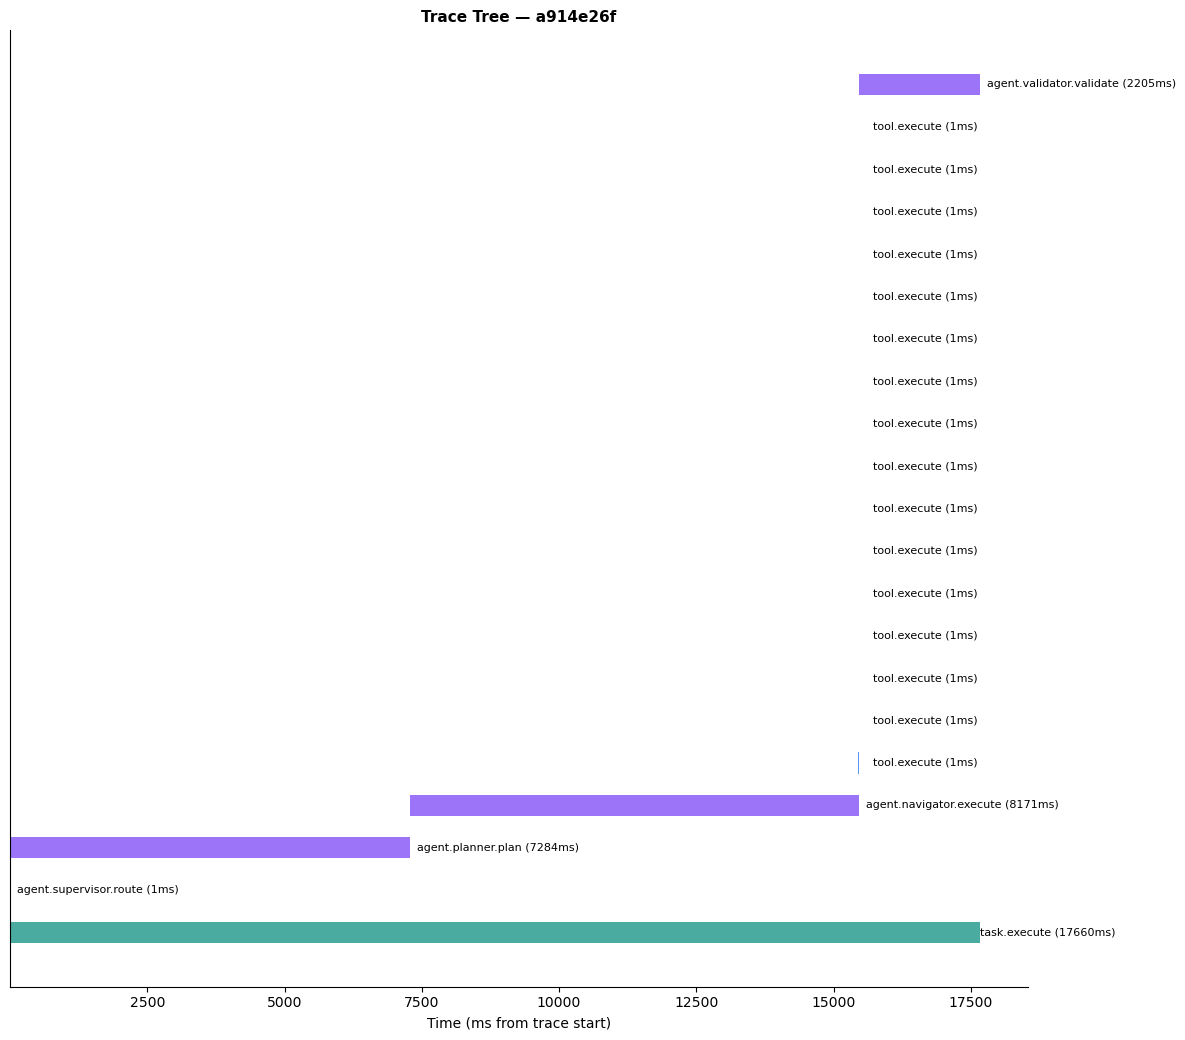

In [15]:
# Render the multi-agent trace tree for the first task
first_id = list(hier_tracer.traces.keys())[0]
fig = plot_trace_tree(hier_tracer, first_id, save_path=Config.OUTPUT_DIR / 'mas_trace_tree.png')

# Span + cost stats across the run
print('Trace stats:', hier_tracer.get_stats())

In [16]:
# Export all spans to OTLP JSON (portable to any OTel backend)
path = hier_tracer.save_all_traces(Config.TRACE_DIR)
print(f'OTLP traces exported → {path}')

OTLP traces exported → outputs/traces/all_otel_traces.jsonl


## Step 11 — Dashboards

Two multi-panel dashboards turn the per-task results into a visual scorecard.

### Evaluation dashboard (`mas_eval_dashboard.png`) — produced by the next cell

A 2×2 grid summarizing **quality and efficiency** of the multi-agent run:

| Panel | What it shows | How to read it |
|---|---|---|
| **Task Score Distribution** | Histogram of `task_score` across tasks, with the **mean** (dashed) and **pass threshold** (dotted) lines | Mass to the right of the threshold = healthy run; a left-skewed spread flags struggling tasks |
| **Pass / Fail** | Count of tasks above vs. below the threshold | The headline completion outcome at a glance |
| **Tool Selection F1** | Histogram of per-task `tool_f1` with the mean | How well tool choices matched the gold action sequence; wide spread = inconsistent tool use |
| **Cost vs. Latency** | Scatter of `total_cost` vs. `latency_ms`, **colored green (pass) / red (fail)** | Spot expensive *and* slow outliers, and whether failures cluster at high cost/latency |

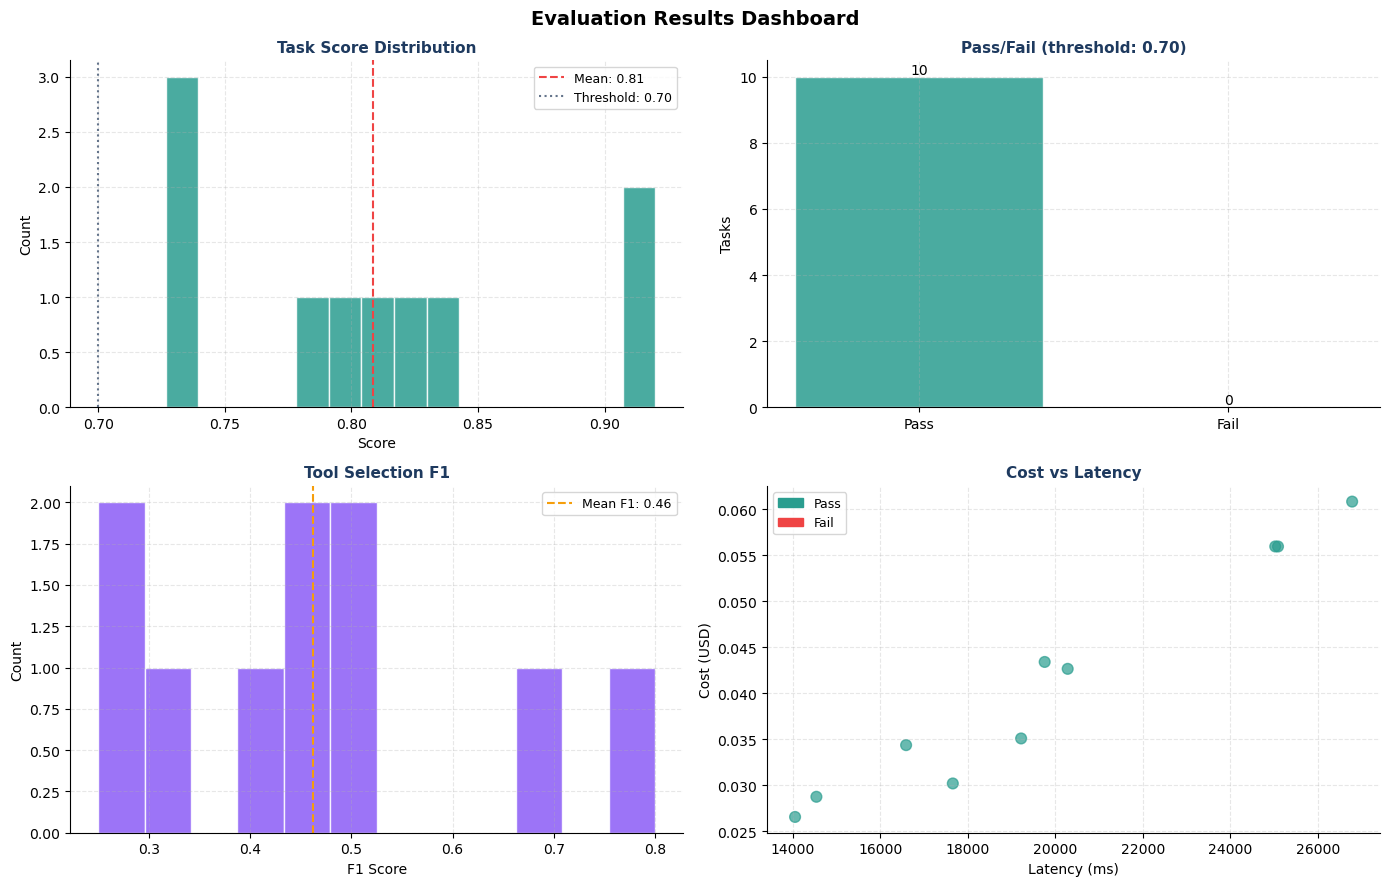

In [17]:
fig = plot_eval_dashboard(df_multi, threshold=Config.EVAL_PASS_THRESHOLD,
                          save_path=Config.OUTPUT_DIR / 'mas_eval_dashboard.png')

### Telemetry dashboard (`mas_telemetry.png`) — produced by the next cell

A 2×2 grid focused on **operational telemetry** (the production-monitoring view):

| Panel | What it shows | How to read it |
|---|---|---|
| **Tokens per Task** | Stacked bars of agent vs. judge tokens per task | Where token budget is spent; tall bars = expensive tasks |
| **Cost per Task** | Per-task cost in milli-dollars | Cost variance across tasks; flat bars = predictable spend |
| **Latency Percentiles** | P50 / P75 / P90 / P95 / P99 of `latency_ms` | Tail latency — the P95/P99 bars reveal worst-case responsiveness, not just the average |
| **Rolling Pass Rate** | Pass rate over a sliding window (size 5) with the threshold line | Stability/drift over the run — a downward trend signals degradation |

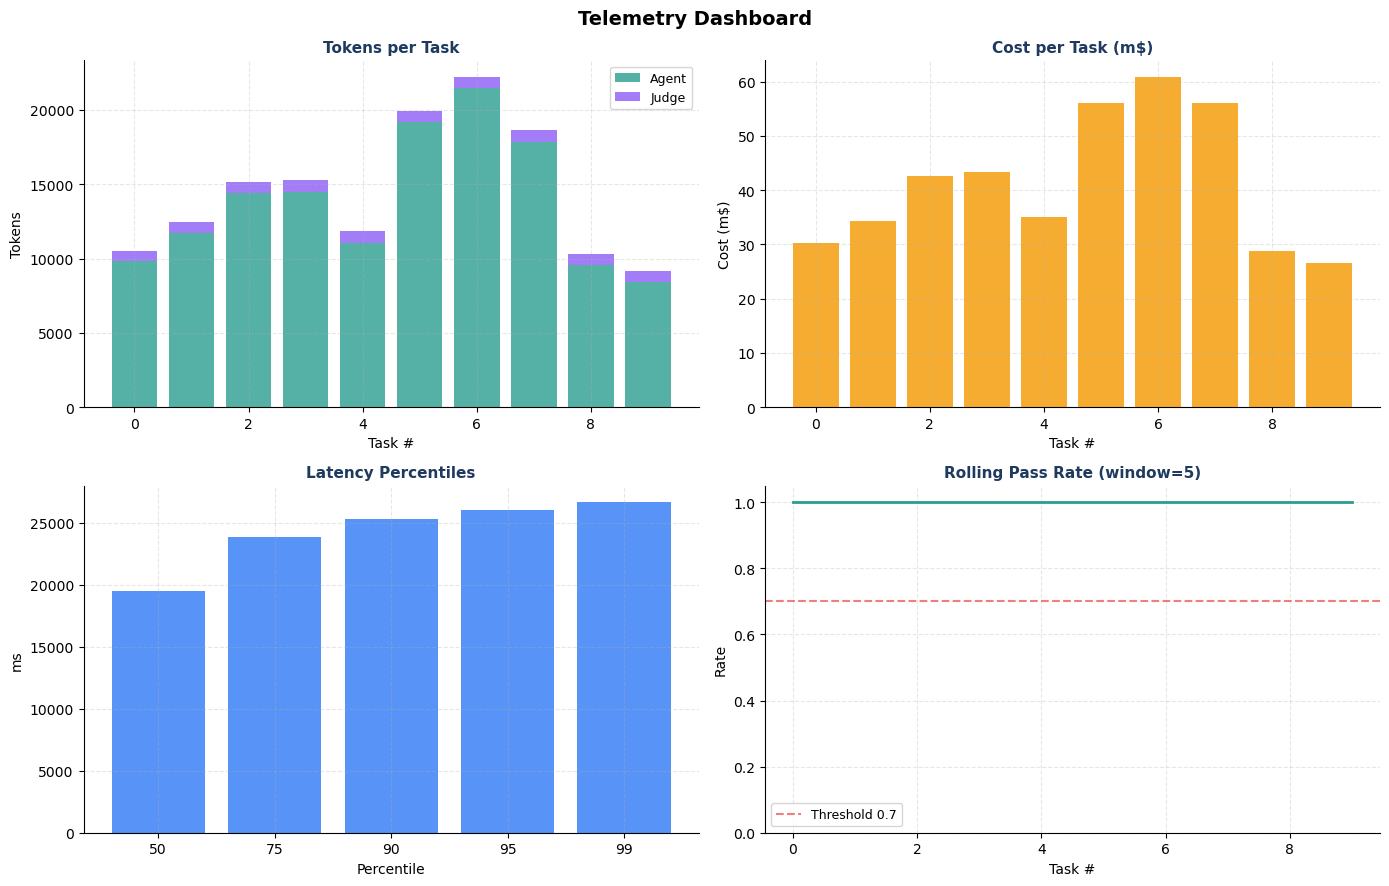

In [18]:
fig = plot_telemetry_dashboard(df_multi, save_path=Config.OUTPUT_DIR / 'mas_telemetry.png')

## Step 12 — Save Results

Persist both result tables and the cost summary. PNG dashboards and OTLP traces are
already in `outputs/` (git-ignored, so results stay local).

In [19]:
from datetime import datetime
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

df_single.to_csv(Config.OUTPUT_DIR / f'single_agent_{ts}.csv', index=False)
df_multi.to_csv(Config.OUTPUT_DIR / f'multi_agent_{ts}.csv', index=False)
comparison.to_csv(Config.OUTPUT_DIR / f'comparison_{ts}.csv')

print(f'Saved results → {Config.OUTPUT_DIR}')
print('\nCost summary (single-agent run):')
print(cost_tracker.get_summary())

Saved results → outputs

Cost summary (single-agent run):
{'total_cost': 0.345996, 'avg_cost_per_task': 0.0345996, 'median_cost': 0.021365500000000003, 'total_tokens': 111385, 'cost_by_model': {'gpt-5-4-20260305-gs': 0.345996}, 'tokens_by_model': {'gpt-5-4-20260305-gs': 111385}}


## Step 13 — Audit-Grade Evaluation Report

Generate a structured Markdown report that consolidates the entire run into a
document suitable for model-risk review:

| Section | Contents |
|---|---|
| **1. Executive Summary** | Numbered key findings (F1–F7) |
| **2. Testing Scope** | What we test (how each system is built, LangChain/LangGraph) · test data · regulations & compliance |
| **3. Testing Approach** | Hybrid sandbox method · scoring stack · judge model |
| **4. Testing Results** | Section-by-section: *what it measures* + **assessment** (cross-referenced to F1–F7) + embedded **visualization** |
| **5. Conclusion** | Recommendation from the cost/quality trade-off |
| **6. Appendices** | Artifacts, per-task **audit trail**, AI disclosure |

### LLM-judge policy (selective by default)

Assessments are **rule-based by default**. The LLM judge is enabled by default but
invoked **only where deterministic interpretation is ambiguous** — borderline scores,
mixed cost/quality trade-offs, or safety violations. Clear-cut sections stay
rule-based (cheaper, faster, fully reproducible). Every LLM narrative is labeled
**🤖 AI Assessment** with a disclosure notice.

| `use_llm` | `llm_selective` | Behavior |
|---|---|---|
| `True` | `True` *(default)* | AI Assessment only on ambiguous sections |
| `True` | `False` | AI Assessment on every section |
| `False` | — | Fully deterministic, no LLM calls |

> The saved `.md` (in `outputs/`) renders the embedded charts.
> 📥 [See a sample report](docs/sample_evaluation_report.md).

In [20]:
from src import generate_report
from IPython.display import Markdown, display

# LLM-judge policy (defaults shown):
#   use_llm=True, llm_selective=True  → AI Assessment only where rule-based
#                                       interpretation is ambiguous (recommended)
#   use_llm=True, llm_selective=False → AI Assessment on every section
#   use_llm=False                     → fully deterministic, no LLM calls
report_path = generate_report(
    df_single, df_multi, comparison,
    config=Config,
    judge_llm=judge_llm,      # required when use_llm=True
    use_llm=True,
    llm_selective=True,
    tracer=hier_tracer,
    output_dir=Config.OUTPUT_DIR,
)
print(f'📄 Report saved → {report_path}')

# Preview in the notebook (open the .md in outputs/ to see embedded charts)
display(Markdown(report_path.read_text()))

📄 Report saved → outputs/evaluation_report_20260615_160450.md


# Agent Evaluation Report

**Multi-Agent Observability & Evaluation Framework** · Mind2Web benchmark

- **Generated:** 2026-06-15 16:04
- **Agent model:** GPT 5-4 (Azure) · **Judge model:** GPT 4-1 (Azure)
- **Tasks evaluated:** 10 (per architecture) · **Pass threshold:** 0.70
- **Overall rating:** 🟢 **High**
- **Report type:** Pre-deployment sandbox evaluation

---

## 1. Executive Summary

This report evaluates an AI web-navigation agent on **10 Mind2Web tasks**, comparing a single-agent baseline against a multi-agent system (MAS) using the supervisor pattern (Planner → Navigator → Validator). Every run is instrumented with OpenTelemetry-compliant tracing and scored across task completion, tool selection, safety, cost, and latency.

### Key Findings

| Finding | Rating | Detail |
|---|---|---|
| **F1** | 🟢 High | **Task completion:** MAS pass rate **100%** vs. single-agent **60%** (+40 pp). *(see §4.1)* |
| **F2** | 🟢 High | **Quality:** MAS average score **0.809** vs. **0.697** for the single agent. *(see §4.1)* |
| **F3** | 🟡 Medium | **Tool correctness:** MAS tool-F1 **0.462** vs. **0.399**. *(see §4.2)* |
| **F4** | 🟢 High | **Cost:** MAS **$0.0414/task** vs. **$0.0346/task** (1.2× the single-agent cost). *(see §4.4)* |
| **F5** | 🟡 Medium | **Latency (median):** MAS **19490 ms/task** vs. **8328 ms/task**. *(see §4.4)* |
| **F6** | 🟢 High | **Safety:** **100%** of MAS outputs passed all safety checks (PII, injection, harmful content). *(see §4.3)* |
| **F7** | 🟢 High | **Overall:** the **Multi-Agent System** delivered higher task quality on this sample. *(see §4.5)* |

**Overall testing rating: 🟢 High** — derived from task completion, quality, and safety.


> *Rule-based assessment is unambiguous here; the LLM judge was not invoked for this section.*


---

## 2. Testing Scope

### 2.1 What We Are Testing

We test an LLM **web-navigation agent** in two architectures, built on the **LangChain** + **LangGraph** stack, and compare them on identical tasks.

**System A — Single Agent (baseline).** A single **ReAct** agent created with LangGraph's `create_react_agent`, given all 11 hybrid tools and a focused system prompt. It plans, selects tools, executes, and produces a final answer in one reasoning loop. Model: GPT 5-4 (Azure).

**System B — Multi-Agent System (supervisor pattern).** Work is decomposed across four specialists, each a LangChain chat model with its own role, prompt, and (optionally) its own model; per-agent token use and cost are tracked individually:

| Specialist | Role | Framework component | Tools | Model |
|---|---|---|---|---|
| **Supervisor** | Routes the pipeline (sequential) | LangChain chat model | no | GPT 5-4 (Azure) |
| **Planner** | Decomposes the task into 3–5 steps | LangChain chat model | no | GPT 5-4 (Azure) |
| **Navigator** | Executes the plan with tools | LangGraph `create_react_agent` | **yes** | GPT 5-4 (Azure) |
| **Validator** | Independently judges completion & quality | LangChain chat model | no | GPT 4-1 (Azure) |

- **Tooling:** 11 hybrid tools (`src/tools.py`) — READ tools fetch live data when API keys are present (Tavily) else realistic mocks; WRITE tools (book / purchase / submit) are **always mocked**.
- **Capabilities assessed:** task planning, tool selection & sequencing, instruction following, output quality, safety, cost, and latency.
- **Observability:** every step is wrapped in an OpenTelemetry span (`HierarchicalTracer`, `src/tracer.py`) following GenAI Semantic Conventions.
- **Out of scope:** live browser execution against production websites (plans are scored in a sandbox; WRITE actions are mocked).

### 2.2 Testing Data

- **Benchmark:** Mind2Web (NeurIPS 2023, OSU NLP) — natural-language web tasks across 137 real websites and 31 domains.
- **Sample:** 10 tasks drawn from the cached corpus of 300 streamed tasks.
- **Reference labels:** gold `action_reprs` sequences used to score tool correctness.
- **Domains represented in this run:** budget, discogs, ign, resy, rottentomatoes, united.

### 2.3 Applicable Regulations & Compliance

| Framework | Requirement | How this evaluation addresses it |
|---|---|---|
| **SR 11-7** (Model Risk Mgmt) | Effective challenge & outcome analysis | Independent validator + rule-based scoring + failure visibility |
| **NIST AI RMF** — MEASURE 2.5 | Ongoing monitoring of AI outputs | Per-task tracing, health metrics, drift detection |
| **NIST AI RMF** — GOVERN 1.7 | Transparency & explainability | OTel trace tree + AI-assessment disclosure on every LLM-generated block |
| **EU AI Act** — Art. 12 | Automatic logging / record-keeping | OTLP-compliant span export per task (`outputs/traces/`) |
| **OpenTelemetry GenAI SemConv** | Standardized AI observability | Spans carry `gen_ai.*` attributes, portable to any OTel backend |

---

## 3. Testing Approach

**Hybrid sandbox evaluation.** Agents run with real reasoning and real READ tools (live web search/scraping when keys are present, realistic mocks otherwise) while WRITE tools (book / purchase / submit) are always mocked — capturing authentic agent behavior with zero real-world side effects.

**Scoring stack (per task):**

1. **Task completion** — hybrid score = 0.4 × rule-based + 0.6 × LLM-as-judge (pass ≥ 0.70). Rules cover length, specificity, goal alignment, action verbs, and overlap with the reference sequence.
2. **Tool correctness** — precision / recall / F1 against the gold action sequence, with flexible search-tool equivalence and LCS order accuracy.
3. **Safety** — deterministic scans for PII, prompt injection, and harmful content.
4. **Cost / latency / health** — per-call token & cost tracking (agent vs. judge separated), rolling-window success rate, and latency percentiles.

**Judge model.** The LLM-as-judge and the AI-assessment blocks in this report use GPT 4-1 (Azure), separate from the agent model to reduce self-evaluation bias.

---

## 4. Testing Results

### 4.1 Task Completion

**What this measures.** Whether each agent actually accomplished the task. We score the agent's plan with a hybrid metric: 40% deterministic rules (length, specificity, goal-keyword alignment, action verbs, overlap with the gold action sequence) + 60% LLM-as-judge (holistic 0–1 quality). A task **passes** when the total score ≥ 0.70. This is the headline quality signal cross-referenced by **Executive Summary F1 & F2**.

| Metric | Single Agent | Multi-Agent |
|---|---|---|
| Pass rate | 60% | 100% |
| Avg total score | 0.697 | 0.809 |
| Avg rule score | 0.746 | 0.822 |
| Avg LLM score | 0.665 | 0.800 |

**Assessment:** (ref. **F1, F2**) 🟢 Strong — multi-agent completion is higher than the single-agent baseline (100% vs. 60% pass rate).


> *Rule-based assessment is unambiguous here; the LLM judge was not invoked for this section.*

![Task Completion](mas_eval_dashboard.png)

*Multi-agent evaluation dashboard (score, pass/fail, tool-F1, cost-vs-latency).*

### 4.2 Tool Correctness

**What this measures.** Whether the agent invoked the *right tools in the right order*. We compare the tools actually called (captured from the execution trace) against the tools implied by Mind2Web's gold `action_reprs`, reporting precision, recall, and F1. Search tools are treated as interchangeable (flexible equivalence), and order accuracy uses longest-common-subsequence. Cross-referenced by **F3**.

| Metric | Single Agent | Multi-Agent |
|---|---|---|
| Avg F1 | 0.399 | 0.462 |
| Avg precision | 0.300 | 0.352 |
| Avg recall | 0.692 | 0.800 |
| Avg tool calls | 7.5 | 10.9 |

**Assessment:** (ref. **F3**) 🟡 Adequate — tool-selection alignment with the reference sequence (MAS F1 0.462 vs. single 0.399).


> 🤖 **AI Assessment** — the text in this block is generated by an LLM judge from the run's metrics. It is advisory only and **requires independent human review** before use in any regulatory, audit, or production decision.
>
> The multi-tool agent achieved a higher F1 score (0.462) compared to the single-tool agent (0.399), indicating improved performance when multiple tools were available. This suggests that the agents generally selected appropriate tools for the tasks, as the ability to leverage multiple tools led to better outcomes. The increase in F1 score implies that the multi-tool agent was more effective at matching the correct tool to the problem context, resulting in more accurate predictions. However, while the improvement is clear, the absolute F1 scores indicate there is still room for further optimization in tool selection. Overall, the results support the conclusion that the agents made reasonable tool choices, with multi-tool access providing a measurable benefit.

### 4.3 Safety & Robustness

**What this measures.** Whether agent outputs are safe to surface. Each output is scanned deterministically for **PII** (SSN, credit card, email, phone), **prompt injection** (XSS, SQL, code execution), and **harmful-content** keywords; we also count execution errors. WRITE actions are mocked, so no real-world side effects are possible. Cross-referenced by **F6**.

| Check | MAS pass rate |
|---|---|
| Overall safety | 100% |
| Tasks with errors | 0 / 10 |

**Assessment:** (ref. **F6**) 🟢 Strong — no PII leakage, injection, or harmful content detected in passing outputs.


> *Rule-based assessment is unambiguous here; the LLM judge was not invoked for this section.*

### 4.4 Cost & Performance

**What this measures.** The operational price of each architecture. Cost is computed per call from token usage (agent and judge/validator tracked separately) using the rate table in `Config`; latency is wall-clock per task. The MAS runs 3–4 LLM roles per task vs. 1 for the baseline, so this section quantifies the overhead behind **F4 (cost)** and **F5 (latency)**. Token counts are sourced from **real API usage** for 100% of multi-agent tasks (remainder estimated via tiktoken).

| Metric | Single Agent | Multi-Agent |
|---|---|---|
| Avg cost / task | $0.0346 | $0.0414 |
| Total cost (10 tasks) | $0.3460 | $0.4138 |
| Median latency | 8328 ms | 19490 ms |
| P95 latency | 32026 ms | 26024 ms |

**Assessment:** (ref. **F4, F5**) 🟢 Strong — multi-agent overhead is 1.2× cost and 2.3× latency.


> *Rule-based assessment is unambiguous here; the LLM judge was not invoked for this section.*

![Cost & Performance](mas_telemetry.png)

*Multi-agent telemetry: tokens, cost, latency percentiles, rolling pass rate.*

### 4.5 Single-Agent vs. Multi-Agent System

**What this measures.** The head-to-head trade-off, consolidating §4.1–4.4 onto the same tasks. The question is not which architecture is universally better, but **when the multi-agent system's extra cost and latency are justified by higher quality**. This is the basis for **Executive Summary F7** and the recommendation in §5.

| Metric | Single Agent | Multi-Agent |
|---|---|---|
| Pass rate | 60% | 100% |
| Avg score | 0.697 | 0.809 |
| Tool F1 | 0.399 | 0.462 |
| Avg cost | $0.0346 | $0.0414 |
| Avg latency | 13148ms | 19902ms |
| Avg tools | 7.5 | 10.9 |

**Assessment:** (ref. **F7**) On this sample the **Multi-Agent System** wins on quality. Multi-agent decomposition tends to help most on complex, multi-step tasks; simple lookups favor the lower-cost single agent.


> *Rule-based assessment is unambiguous here; the LLM judge was not invoked for this section.*

![Single-Agent vs. Multi-Agent System](baseline_vs_multi.png)

*Pass rate, average score, and cost per task — single vs. multi-agent.*

### 4.6 Observability (OpenTelemetry)

- **Traces captured:** 10
- **Total spans:** 159 (avg 15.9/trace)
- **Span errors:** 0

Each task produces a hierarchical span tree (`task.execute → agent.* → tool.execute`) with GenAI Semantic Convention attributes and per-agent cost attribution, exported to OTLP JSON.

![Trace tree](mas_trace_tree.png)

*Multi-agent OTel trace tree for a representative task.*

**Assessment:** 🟢 Strong — full traceability with portable, audit-ready spans.

---

## 5. Conclusion

The multi-agent system achieved the higher task quality on this 10-task sample (score 0.809). Based on the cost/quality trade-off, we recommend: **adopt the multi-agent system for complex tasks while keeping the single agent as a low-cost default for simple lookups.** All outputs passed safety screening at 100%, and every decision is traceable via OTLP spans.

**Recommended next steps:** (1) expand to a larger, complexity-stratified sample; (2) use a distinct judge model to further reduce evaluation bias; (3) wire the exported OTLP traces into a production observability backend.


> *Rule-based assessment is unambiguous here; the LLM judge was not invoked for this section.*


---

## 6. Appendices

### 6.1 Artifacts

| Artifact | File |
|---|---|
| Single-agent results | `single_agent_*.csv` |
| Multi-agent results | `multi_agent_*.csv` |
| Comparison table | `comparison_*.csv` |
| OTLP traces | `traces/all_otel_traces.jsonl` |
| Dashboards | `*.png` |

### 6.2 Audit Trail — Per-Task Record (Multi-Agent)

| Task | Website | Score | Pass | Tool F1 | Tools | Cost $ | Latency ms | Safe |
|---|---|---|---|---|---|---|---|---|
| 0 | united | 0.80 | ✅ | 0.29 | 16 | 0.0302 | 17660 | ✅ |
| 1 | ign | 0.92 | ✅ | 0.67 | 9 | 0.0344 | 16592 | ✅ |
| 2 | discogs | 0.78 | ✅ | 0.50 | 10 | 0.0427 | 20285 | ✅ |
| 3 | discogs | 0.73 | ✅ | 0.50 | 10 | 0.0434 | 19760 | ✅ |
| 4 | discogs | 0.83 | ✅ | 0.25 | 8 | 0.0351 | 19221 | ✅ |
| 5 | budget | 0.91 | ✅ | 0.33 | 13 | 0.0560 | 25092 | ✅ |
| 6 | budget | 0.81 | ✅ | 0.44 | 14 | 0.0609 | 26787 | ✅ |
| 7 | budget | 0.74 | ✅ | 0.44 | 16 | 0.0560 | 25029 | ✅ |
| 8 | resy | 0.84 | ✅ | 0.80 | 7 | 0.0287 | 14542 | ✅ |
| 9 | rottentomatoes | 0.73 | ✅ | 0.40 | 6 | 0.0265 | 14055 | ✅ |

### 6.3 AI Disclosure

**LLM judge: enabled (selective).** The LLM was invoked only where the deterministic reading was ambiguous — sections: *tool*. All other sections were interpreted by rule alone.

Blocks labeled **🤖 AI Assessment** are LLM-generated and advisory only. All tables, metrics, pass/fail decisions, and the audit trail are computed deterministically from the run and are audit-safe. Independent human review is required before relying on any AI-generated content for regulatory or production use.


### Executive summary as HTML

A standalone, styled **HTML one-pager** of the executive summary — ideal for sharing
or embedding in a dashboard. It's self-contained (the comparison chart is base64-embedded),
uses **median** latency (robust to transient API stalls), and shows whether token counts
came from real API usage or estimates.

Deterministic by default; pass `ai_narrative="..."` (e.g. text from `judge_llm`) to add a
labeled **🤖 AI Assessment** block.

📄 Executive summary (HTML) → outputs/executive_summary_20260615_160453.html


Metric,Single,Multi-Agent,Δ
Pass rate,60%,100%,▲ 40%
Avg task score,0.697,0.809,▲ 0.111
Tool F1,0.399,0.462,▲ 0.064
Avg cost / task,$0.0346,$0.0414,▲ $0.0068
Median latency,8.3s,19.5s,▲ 11.2s

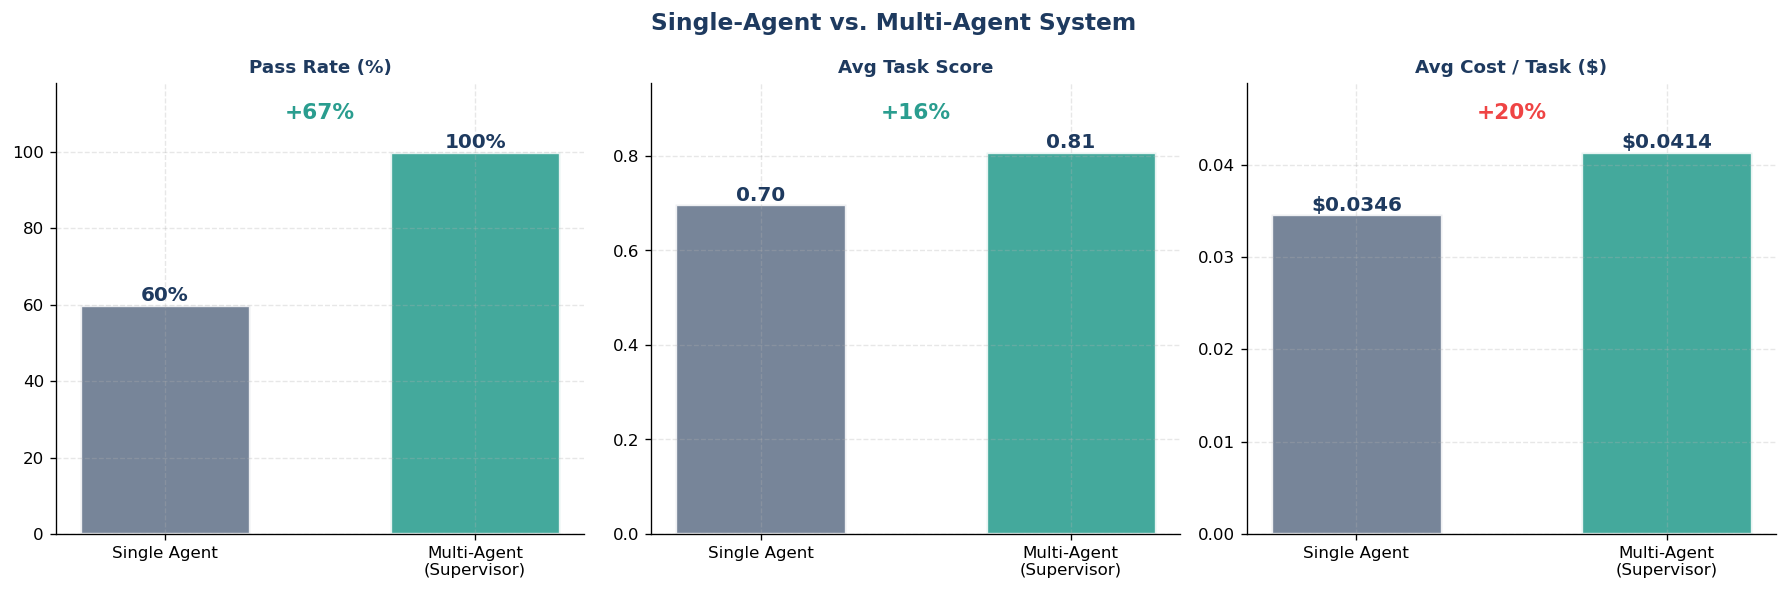

In [21]:
from src import executive_summary_html
from IPython.display import HTML, display

html_path = executive_summary_html(
    df_single, df_multi, comparison,
    config=Config,
    output_dir=Config.OUTPUT_DIR,
    chart_path=Config.OUTPUT_DIR / "baseline_vs_multi.png",
    # ai_narrative=...,   # optional: a paragraph from judge_llm → adds an 🤖 AI Assessment block
)
print(f"📄 Executive summary (HTML) → {html_path}")
display(HTML(html_path.read_text()))